Preprocessed Data for Milestone 3:
   no_of_employees  prevailing_wage  company_age  wage_per_employee_size  \
0         1.374348         0.668854    -0.506974               -0.054186   
1        -0.258942        -1.164823    -0.967846               -0.059255   
2         1.380312        -1.485141    -1.659155               -0.063229   
3        -0.600456         0.630203     1.428689               -0.037091   
4         1.652816        -1.061494     0.046072               -0.061679   

   country_of_applicant   continent   visa_type  region_of_employment  \
0            187.119104  186.158254  186.298717            184.783810   
1            185.374535  185.718561  185.122984            186.066857   
2            184.664558  186.385895  185.845383            184.783810   
3            182.722625  186.142942  186.388847            185.917743   
4            182.722625  186.142942  184.656351            185.964664   

     season_sin    season_cos  
0 -1.000000e+00 -1.836970e-16  
1 -1.

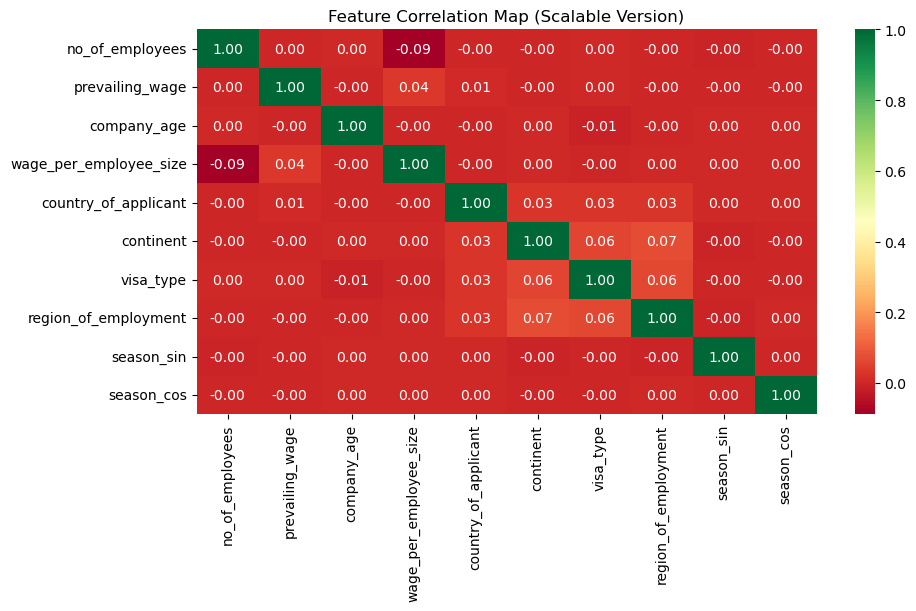

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# 1. Load your dataset
df = pd.read_csv('data\\VisaFile.csv')


# 1. Ensure company_age is created before defining the pipeline
# Based on your data: company_age = current_year - yr_of_estab
current_year = 2024
df['company_age'] = current_year - df['yr_of_estab']

# 2. Map seasons to numbers and create cyclical features
season_map = {'Spring': 0, 'Summer': 1, 'Fall': 2, 'Winter': 3}
df['season_num'] = df['application_season'].map(season_map)
df['season_sin'] = np.sin(2 * np.pi * df['season_num'] / 4)
df['season_cos'] = np.cos(2 * np.pi * df['season_num'] / 4)

# 3. Create Wage-to-Efficiency Ratio
df['wage_per_employee_size'] = df['prevailing_wage'] / (df['no_of_employees'] + 1)

# --- SCALABLE PREPROCESSING PIPELINE ---

# List the columns exactly as they appear in 'df'
target_features = ['country_of_applicant', 'continent', 'visa_type', 'region_of_employment']
numeric_features = ['no_of_employees', 'prevailing_wage', 'company_age', 'wage_per_employee_size']

# IMPORTANT: Define X by selecting ONLY the features we want to process.
# This avoids the KeyError by ensuring we only pass columns that exist.
X = df[target_features + numeric_features + ['season_sin', 'season_cos']]
y = df['processing_time_days']

# Define the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('tgt', TargetEncoder(target_type='continuous'), target_features)
    ],
    remainder='passthrough' # This keeps the season_sin/cos columns
)

# Fit and Transform
X_processed = preprocessor.fit_transform(X, y)

# Convert back to DataFrame to verify
# Note: remainder='passthrough' adds columns at the end
processed_cols = numeric_features + target_features + ['season_sin', 'season_cos']
df_final = pd.DataFrame(X_processed, columns=processed_cols)

print("Preprocessed Data for Milestone 3:")
print(df_final.head())

# --- VISUALIZATION FOR MILESTONE 2 ---
plt.figure(figsize=(10, 5))
sns.heatmap(df_final.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation Map (Scalable Version)")
plt.show()